
## Kovács Levente, Tasnádi Bálint

## Objectives

In our machine learning project, we aim to develop a convulational neural network (CNN) based system that can be used to detect pathologic malformations (in particular, signs of Invasive Ductal Carcinoma) in breast tissue based on hystology slides.

We plan to use the following dataset: https://www.kaggle.com/datasets/paultimothymooney/breast-histopathology-images Introduction to Machine Learning project: Breast cancer classificationthology-images

Our plan is to build a classifier by using approximately 80% of our posessed data. Furthermore, we intend to create a confusion matrix, so we can evaluate our model's performance.

## Subject overview

IDC is the most frequent form of breast cancer. In order to form a prognosis, the agressiveness of the cancer must be evaluated. This is done by human visual inspection of histopathology slides, where the (small) cancerous regions are identified in the large benign background.

ML approaches before CNN (SVM, PCA, autoencoders, random forest) relied on hand-crafted feature detection (colour, edges, density, ...), and achieved accuracies around 80%.

In [1]:
from glob import glob #filenames
from os import path

import cv2 #image processing

import matplotlib.pyplot as plt

import pandas as pd #data storage
import numpy as np
import kagglehub
import random

In [2]:
# Download latest version
path = kagglehub.dataset_download("paultimothymooney/breast-histopathology-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'breast-histopathology-images' dataset.
Path to dataset files: /kaggle/input/breast-histopathology-images


## Dataset description

Humongous (3GB) dataset from 162 breast cancer specimens, broken into 277,524 50x50 patches (198,738 negative, 78,786 positive).

In [3]:
data_filenames = glob(path + '/IDC_regular_ps50_idx5/**/**/*.png') #finds all .png files in data/ and subdirectories

print(f'Found {len(data_filenames)} files')

Found 277524 files


for playing around, let's select 10k positive and 10k negative images. There is a 1:2 class imbalance in the original dataset, we can circumvent it by only working on a small subset for now.

In [4]:
positive_filepaths = [f for f in data_filenames if f.endswith('_class1.png')]
negative_filepaths = [f for f in data_filenames if f.endswith('_class0.png')]

num_samples = 10000

selected_positive_filepaths = random.sample(positive_filepaths, min(num_samples, len(positive_filepaths)))
selected_negative_filepaths = random.sample(negative_filepaths, min(num_samples, len(negative_filepaths)))

print(f'Selected {len(selected_positive_filepaths)} positive images and {len(selected_negative_filepaths)} negative images.')

# Combine and shuffle the selected file paths
selected_filepaths = selected_positive_filepaths + selected_negative_filepaths
random.shuffle(selected_filepaths)

Selected 10000 positive images and 10000 negative images.


data processing: save into image and label arrays

In [5]:
def load_and_preprocess_image(filepath, target_size=(50, 50)):
    img = cv2.imread(filepath) #read image at path
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB

    #check if 50x50x3
    if img.shape[0] != target_size[0] or img.shape[1] != target_size[1]:
        return None # Exclude images that are not 50x50
    return img


images = []
labels = []

for filepath in selected_filepaths:
    img = load_and_preprocess_image(filepath)
    if img is not None:
        images.append(img)
        # Extract label from filename (class0 or class1)
        label = int(filepath.split('_class')[-1].split('.')[0])
        labels.append(label)

data_20k_images = np.array(images)
data_20k_labels = np.array(labels)

print(f'Shape of loaded images array: {data_20k_images.shape}')
print(f'Shape of loaded labels array: {data_20k_labels.shape}')

Shape of loaded images array: (19889, 50, 50, 3)
Shape of loaded labels array: (19889,)


In [ ]:
np.save('data_20k_images.npy', data_20k_images)

## Example images

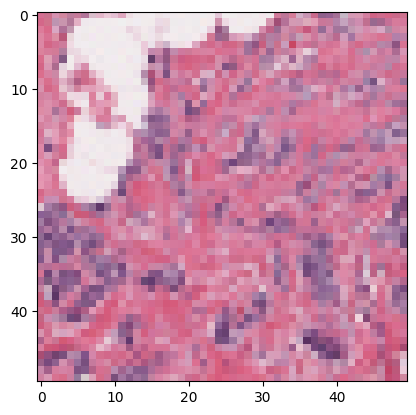

In [6]:
if len(data_20k_images) > 0:
    plt.imshow(data_20k_images[0])
else:
    print("data_20k_images is empty. Please check the data loading steps in earlier cells, especially cell H79PUecxZrLO.")

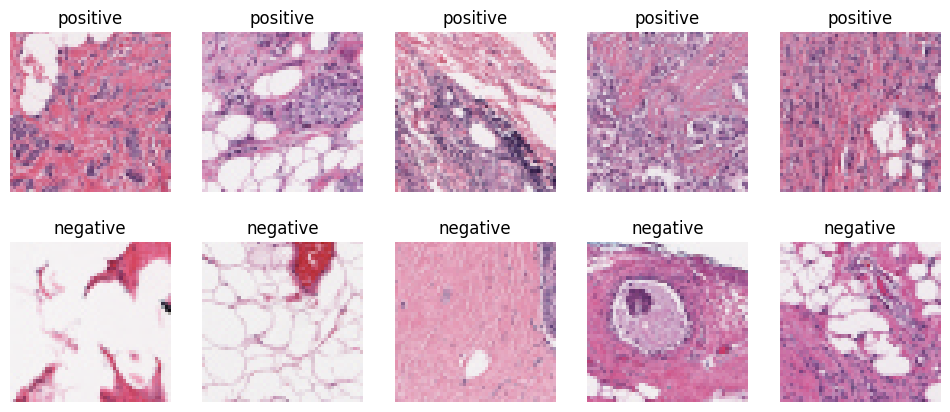

In [7]:
positive_images_display = []
negative_images_display = []

positive_count = 0
negative_count = 0

for i in range(len(data_20k_images)):
    if data_20k_labels[i] == 1 and positive_count < 5: #if positive save to positive
        positive_images_display.append(data_20k_images[i])
        positive_count += 1
    elif data_20k_labels[i] == 0 and negative_count < 5: #if negative save to negative
        negative_images_display.append(data_20k_images[i])
        negative_count += 1

    if positive_count == 5 and negative_count == 5: #break if done
        break

plt.figure(figsize=(12, 5))

#positive
for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(positive_images_display[i])
    plt.axis('off')
    plt.title("positive")

#negative
for i in range(5):
    plt.subplot(2, 5, i + 6)
    plt.imshow(negative_images_display[i])
    plt.title("negative")
    plt.axis('off')

### Complete slide

In [8]:
import re

# Define the base directory for the specific slide
slide_base_dir = '/kaggle/input/breast-histopathology-images/IDC_regular_ps50_idx5/10253'

# Find all .png files within the 0 and 1 subfolders of the specified slide
all_slide_filepaths = glob(f'{slide_base_dir}/**/*.png', recursive=True)

print(f'Found {len(all_slide_filepaths)} image patches for slide 10253.')

Found 549 image patches for slide 10253.


In [9]:
def load_mosaic_image_with_coords(filepath):
    img = cv2.imread(filepath) # Read image
    if img is None:
        return None, None, None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB

    # Extract x and y coordinates from the filename
    match = re.search(r'_x(\d+)_y(\d+)_', filepath)
    if match:
        x = int(match.group(1))
        y = int(match.group(2))
        return img, x, y
    return None, None, None

# Assuming each mosaic image is 50x50 pixels
MOSAIC_SIZE = 50

In [10]:
mosaic_images = []
coords = []

min_x, max_x = float('inf'), float('-inf')
min_y, max_y = float('inf'), float('-inf')

for filepath in all_slide_filepaths:
    img, x, y = load_mosaic_image_with_coords(filepath)
    if img is not None:
        mosaic_images.append(img)
        coords.append((x, y))
        min_x = min(min_x, x)
        max_x = max(max_x, x)
        min_y = min(min_y, y)
        max_y = max(max_y, y)

print(f'Processed {len(mosaic_images)} mosaic images.')

# Calculate the dimensions of the full slide
# The width will be (max_x - min_x + MOSAIC_SIZE) and height (max_y - min_y + MOSAIC_SIZE)
# Since coordinates are top-left corners, add MOSAIC_SIZE to get the full span
full_slide_width = max_x - min_x + MOSAIC_SIZE
full_slide_height = max_y - min_y + MOSAIC_SIZE

print(f'Full slide dimensions: {full_slide_width}x{full_slide_height} pixels.')

# Create a blank canvas for the full slide
full_slide = np.zeros((full_slide_height, full_slide_width, 3), dtype=np.uint8)

Processed 549 mosaic images.
Full slide dimensions: 2500x2000 pixels.


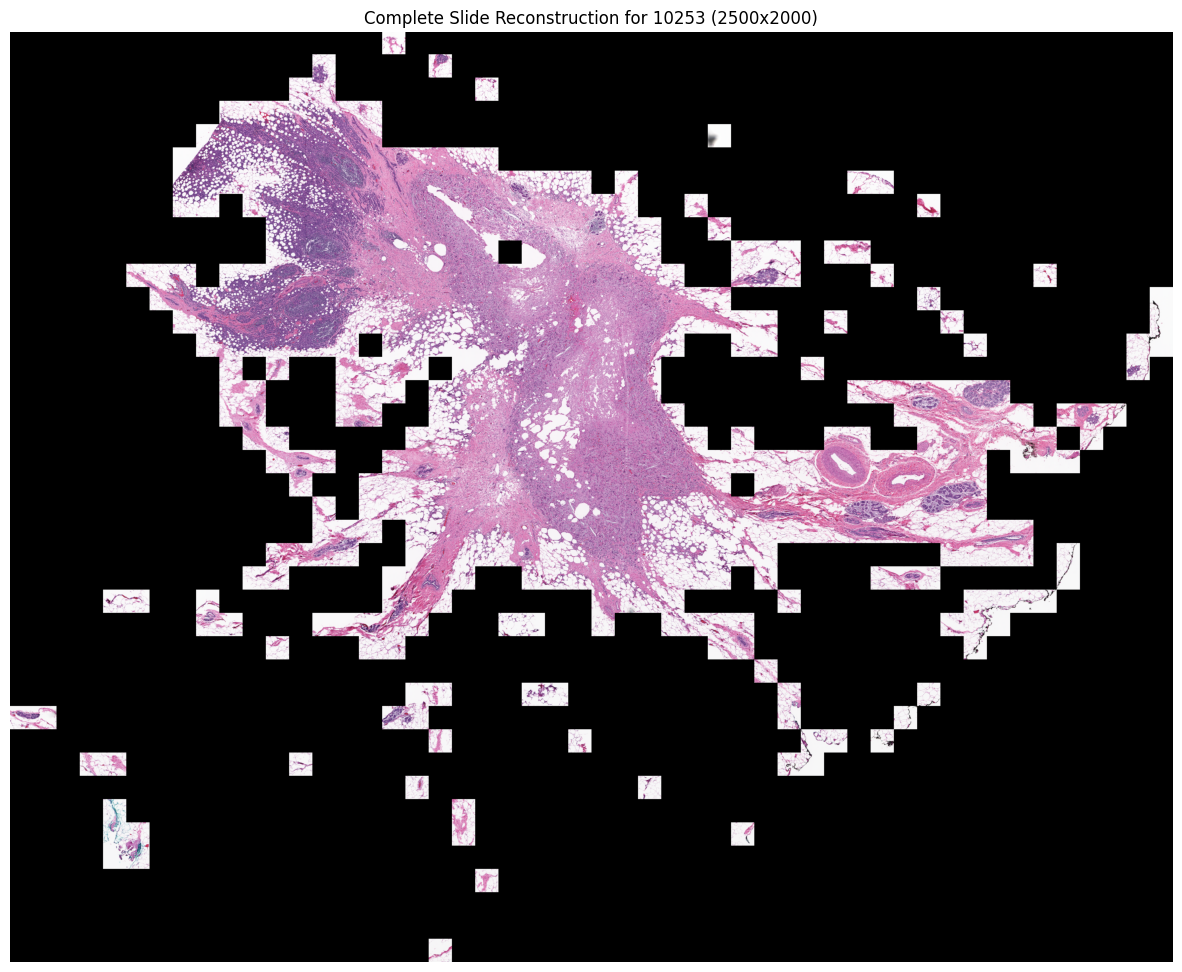

In [11]:
for i, (img, (x, y)) in enumerate(zip(mosaic_images, coords)):
    # Calculate relative position on the canvas
    rel_x = x - min_x
    rel_y = y - min_y
    full_slide[rel_y : rel_y + MOSAIC_SIZE, rel_x : rel_x + MOSAIC_SIZE] = img

# Display the complete slide
plt.figure(figsize=(15, 15))
plt.imshow(full_slide)
plt.title(f'Complete Slide Reconstruction for 10253 ({full_slide_width}x{full_slide_height})')
plt.axis('off')
plt.show()

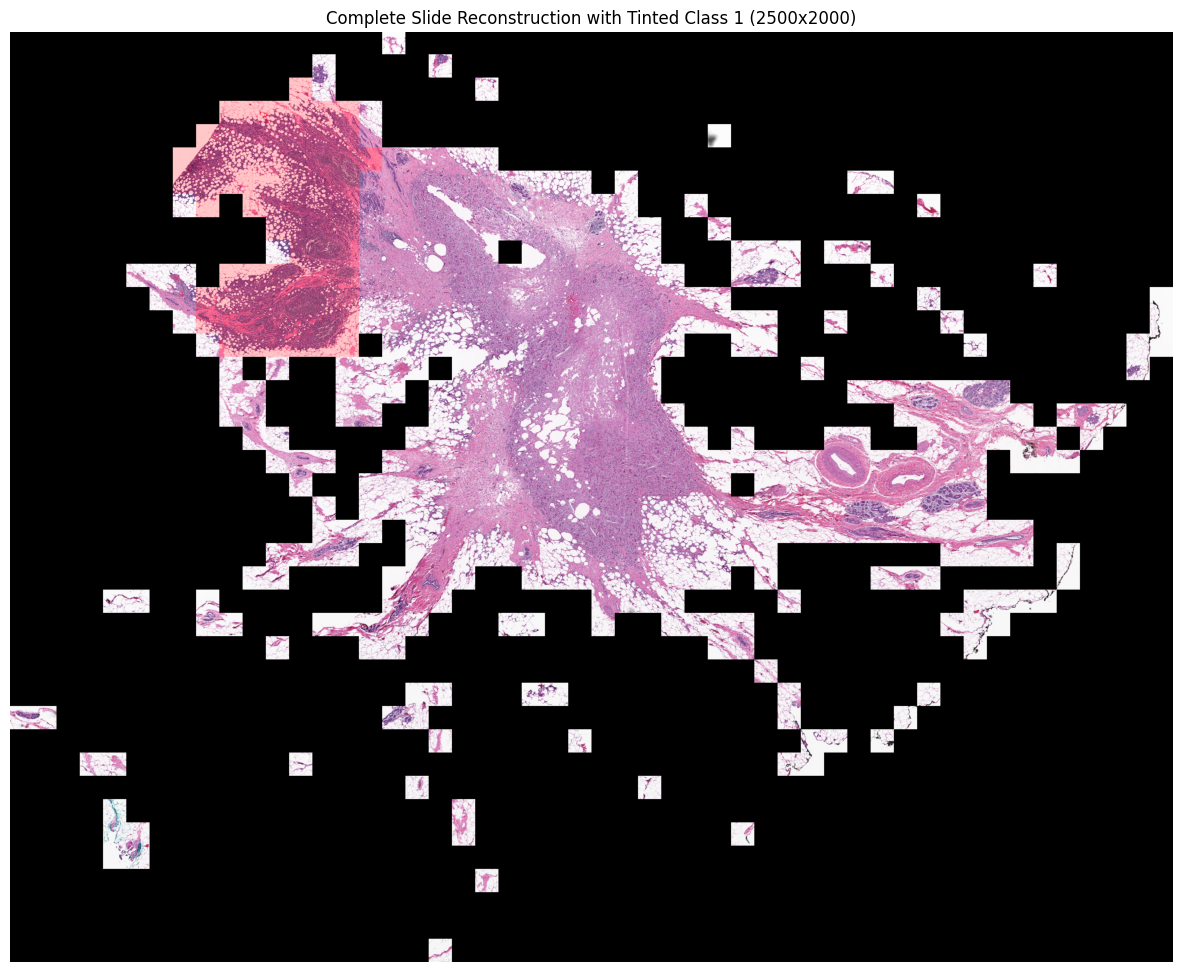

In [12]:
# Re-create a blank canvas for the full slide, this time for tinted images
full_slide_tinted = np.zeros((full_slide_height, full_slide_width, 3), dtype=np.uint8)

for filepath in all_slide_filepaths:
    img, x, y = load_mosaic_image_with_coords(filepath)
    if img is not None:
        img_to_place = img.copy() # Make a copy to avoid modifying original loaded images if they were stored

        # Check if the image is from class1 (cancerous)
        if '_class1.png' in filepath:
            # Apply a red tint: boost red channel, slightly reduce green and blue
            img_to_place[:, :, 0] = np.clip(img_to_place[:, :, 0] * 1.2, 0, 255) # Red channel (boost)
            img_to_place[:, :, 1] = np.clip(img_to_place[:, :, 1] * 0.8, 0, 255) # Green channel (reduce)
            img_to_place[:, :, 2] = np.clip(img_to_place[:, :, 2] * 0.8, 0, 255) # Blue channel (reduce)

        # Calculate relative position on the canvas
        rel_x = x - min_x
        rel_y = y - min_y
        full_slide_tinted[rel_y : rel_y + MOSAIC_SIZE, rel_x : rel_x + MOSAIC_SIZE] = img_to_place

# Display the complete slide with tinted class1 images
plt.figure(figsize=(15, 15))
plt.imshow(full_slide_tinted)
plt.title(f'Complete Slide Reconstruction with Tinted Class 1 ({full_slide_width}x{full_slide_height})')
plt.axis('off')
plt.show()

In [21]:
if history is not None:
    # Find the epoch with the minimum validation loss
    best_epoch_index = np.argmin(history.history['val_loss'])
    best_val_loss = history.history['val_loss'][best_epoch_index]
    best_val_accuracy = history.history['val_accuracy'][best_epoch_index]


    print(f"EarlyStopping reverted to epoch {best_epoch_index} with the best validation loss:")
    print(f"  Validation Loss: {best_val_loss:.4f}")
    print(f"  Validation Accuracy: {best_val_accuracy:.4f}")
else:
    print("History object not found. Please ensure the model was trained with 'history = model.fit(...)'")

EarlyStopping reverted to epoch 12 with the best validation loss:
  Validation Loss: 0.4188
  Validation Accuracy: 0.8205


The red tinted regions were manually identified to be cancerous by a pathologist. Our goal is to get a similar identification using a CNN.

## Train, test, validate sets


We separated the data, the ratio was the following: 80% for training, 10% for validation and 10% testing. The separation was done with the help of sklearn library.

In [14]:
import numpy as np
from sklearn.model_selection import train_test_split

X = data_20k_images
y = data_20k_labels

X = X.astype('float32') / 255.0

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(X_train.shape[0])
print(X_val.shape[0])
print(X_test.shape[0])

15911
1989
1989


The CNN model was built. We used tensorflow because it is a high level API which means it is easier for us to build and handle the network. In case we used PyTorch the process would be slightly complicated. Moreover, tensorflow was created by Google so as Colab, which is our running envinronment this time, overall this makes a perfect match.

## Model

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(50, 50, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Recall()])

model.summary()
print("Success!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 9, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5184)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       331,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 388,225 (1.48 MB)

 Trainable params: 388,225 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

Success!


## Training:

In [16]:
from tensorflow.keras.callbacks import EarlyStopping #helps prevent overfitting

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/30
498/498 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.7409 - loss: 0.5262 - recall: 0.7238 - val_accuracy: 0.7763 - val_loss: 0.4828 - val_recall: 0.7950
Epoch 2/30
498/498 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7877 - loss: 0.4697 - recall: 0.7794 - val_accuracy: 0.7687 - val_loss: 0.4772 - val_recall: 0.7060
Epoch 3/30
498/498 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7972 - loss: 0.4550 - recall: 0.7908 - val_accuracy: 0.7919 - val_loss: 0.4569 - val_recall: 0.8200
Epoch 4/30
498/498 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8020 - loss: 0.4440 - recall: 0.8062 - val_accuracy: 0.7863 - val_loss: 0.4669 - val_recall: 0.7120
Epoch 5/30
498/498 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8023 - loss: 0.4432 - recall: 0.7992 - val_accuracy: 0.7858 - val_loss: 0.4590 - val_recall: 0.7490
Epoch 6/30
498/498 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8128 - loss: 0.4269 - recall: 0.8142 - val_accuracy: 0.7838 - val_loss: 0.4551 - val_recall: 0.8730
Ep

In [17]:
model.save('breast_cancer_model.keras')
print("Success!")

Success!


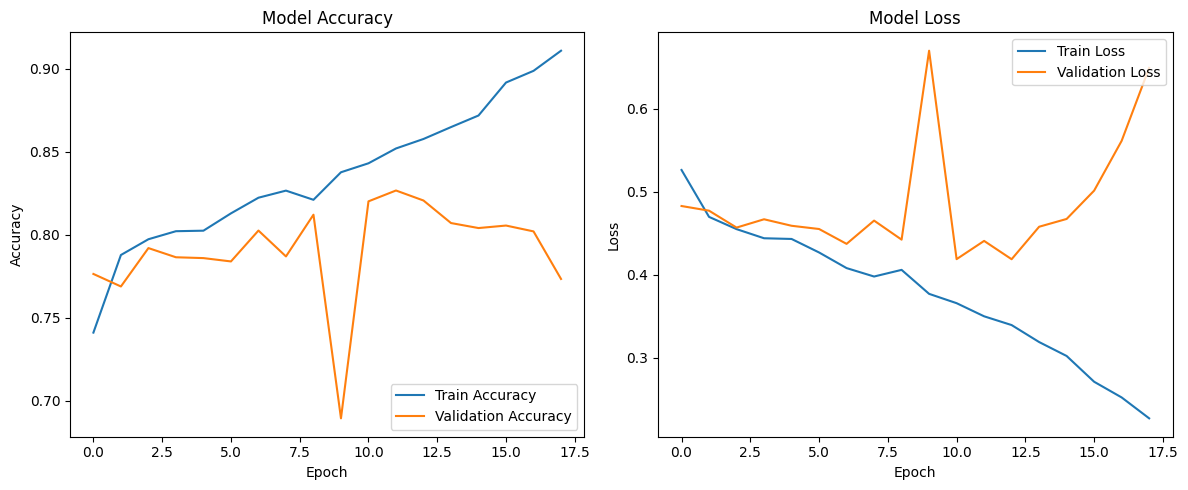

In [18]:
# Plotting the Training and Validation Accuracy & Loss
plt.figure(figsize=(12, 5))

# Accuracy Graph
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')

# Loss Graph
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Confusion matrix:

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


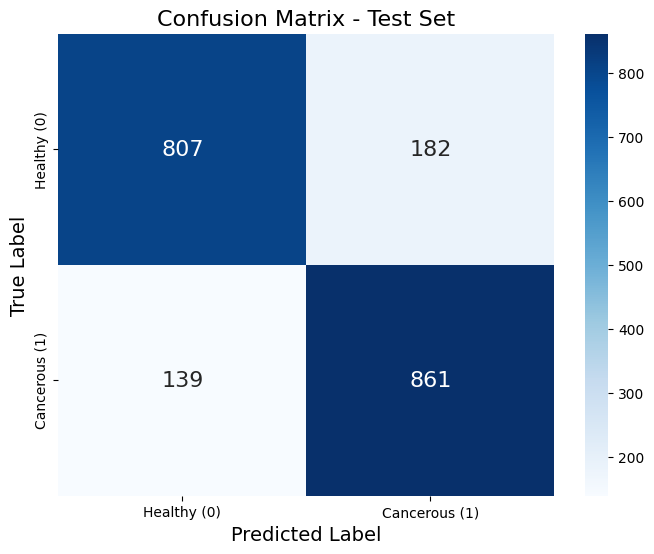

               precision    recall  f1-score   support

  Healthy (0)       0.85      0.82      0.83       989
Cancerous (1)       0.83      0.86      0.84      1000

     accuracy                           0.84      1989
    macro avg       0.84      0.84      0.84      1989
 weighted avg       0.84      0.84      0.84      1989



In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy (0)', 'Cancerous (1)'],
            yticklabels=['Healthy (0)', 'Cancerous (1)'],
            annot_kws={"size": 16})

plt.title('Confusion Matrix - Test Set', fontsize=16)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.show()

print(classification_report(y_test, y_pred, target_names=['Healthy (0)', 'Cancerous (1)']))

Training on a larger database, in this case we used as much data as we could to complete the training, however we held the balance between the number of healthy and cancerous training pictures. This method is called undersampling.

In [ ]:
import pandas as pd
from glob import glob
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

all_filepaths = glob('/root/.cache/kagglehub/datasets/paultimothymooney/breast-histopathology-images/versions/1/IDC_regular_ps50_idx5/**/*.png', recursive=True)
labels = ['1' if f.endswith('_class1.png') else '0' for f in all_filepaths]

df = pd.DataFrame({'filepath': all_filepaths, 'label': labels})

df_healthy = df[df['label'] == '0']
df_cancer = df[df['label'] == '1']

min_size = min(len(df_healthy), len(df_cancer))
df_healthy_balanced = df_healthy.sample(n=min_size, random_state=42)
df_cancer_balanced = df_cancer.sample(n=min_size, random_state=42)

df_balanced = pd.concat([df_healthy_balanced, df_cancer_balanced]).sample(frac=1, random_state=42).reset_index(drop=True)

train_df, temp_df = train_test_split(df_balanced, test_size=0.20, random_state=42, stratify=df_balanced['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['label'])

batch_size = 64
datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_dataframe(
    dataframe=train_df, x_col='filepath', y_col='label',
    target_size=(50, 50), class_mode='binary', batch_size=batch_size, shuffle=True
)

val_generator = datagen.flow_from_dataframe(
    dataframe=val_df, x_col='filepath', y_col='label',
    target_size=(50, 50), class_mode='binary', batch_size=batch_size, shuffle=False
)

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(50, 50, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Recall()])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop]
)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

test_generator = datagen.flow_from_dataframe(
    dataframe=test_df, x_col='filepath', y_col='label',
    target_size=(50, 50), class_mode='binary', batch_size=batch_size, shuffle=False
)

test_generator.reset()
y_pred_prob = model.predict(test_generator)

y_pred = (y_pred_prob > 0.5).astype(int)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy (0)', 'Cancerous (1)'],
            yticklabels=['Healthy (0)', 'Cancerous (1)'],
            annot_kws={"size": 16})

plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.show()

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=['Healthy (0)', 'Cancerous (1)']))

We conducted the training without balanced dataset out of curiosity and without further change in the model.

In [ ]:
import pandas as pd
from glob import glob
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

all_filepaths = glob('/root/.cache/kagglehub/datasets/paultimothymooney/breast-histopathology-images/versions/1/IDC_regular_ps50_idx5/**/*.png', recursive=True)
labels = ['1' if f.endswith('_class1.png') else '0' for f in all_filepaths]

df = pd.DataFrame({'filepath': all_filepaths, 'label': labels})

train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['label'])

batch_size = 64
datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_dataframe(
    dataframe=train_df, x_col='filepath', y_col='label',
    target_size=(50, 50), class_mode='binary', batch_size=batch_size, shuffle=True
)

val_generator = datagen.flow_from_dataframe(
    dataframe=val_df, x_col='filepath', y_col='label',
    target_size=(50, 50), class_mode='binary', batch_size=batch_size, shuffle=False
)

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(50, 50, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Recall()])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop]
)

434/434 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step


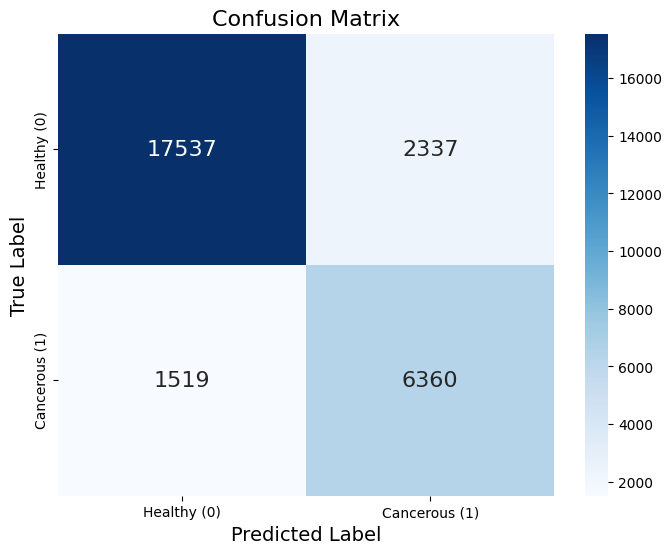


--- CLASSIFICATION REPORT ---
               precision    recall  f1-score   support

  Healthy (0)       0.92      0.88      0.90     19874
Cancerous (1)       0.73      0.81      0.77      7879

     accuracy                           0.86     27753
    macro avg       0.83      0.84      0.83     27753
 weighted avg       0.87      0.86      0.86     27753



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

test_generator.reset()
y_pred_prob = model.predict(test_generator)

y_pred = (y_pred_prob > 0.5).astype(int)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy (0)', 'Cancerous (1)'],
            yticklabels=['Healthy (0)', 'Cancerous (1)'],
            annot_kws={"size": 16})

plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.show()

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=['Healthy (0)', 'Cancerous (1)']))

In our next training we use weights.By introducing class weights, the model sacrificed its deceptively high overall accuracy to become medically much more sensitive and reliable in detecting critical cancerous cases.

Found 222019 validated image filenames belonging to 2 classes.
Found 27752 validated image filenames belonging to 2 classes.
Found 27753 validated image filenames belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
3470/3470 ━━━━━━━━━━━━━━━━━━━━ 170s 47ms/step - accuracy: 0.8028 - loss: 0.4417 - recall: 0.7946 - val_accuracy: 0.8193 - val_loss: 0.4132 - val_recall: 0.8106
Epoch 2/30
3470/3470 ━━━━━━━━━━━━━━━━━━━━ 124s 36ms/step - accuracy: 0.8329 - loss: 0.3871 - recall: 0.8345 - val_accuracy: 0.8472 - val_loss: 0.3634 - val_recall: 0.8389
Epoch 3/30
3470/3470 ━━━━━━━━━━━━━━━━━━━━ 106s 31ms/step - accuracy: 0.8410 - loss: 0.3685 - recall: 0.8448 - val_accuracy: 0.8472 - val_loss: 0.3637 - val_recall: 0.8562
Epoch 4/30
3470/3470 ━━━━━━━━━━━━━━━━━━━━ 107s 31ms/step - accuracy: 0.8455 - loss: 0.3593 - recall: 0.8512 - val_accuracy: 0.8207 - val_loss: 0.4040 - val_recall: 0.9024
Epoch 5/30
3470/3470 ━━━━━━━━━━━━━━━━━━━━ 105s 30ms/step - accuracy: 0.8474 - loss: 0.3528 - recall: 0.8567 - val_accuracy: 0.8590 - val_loss: 0.3292 - val_recall: 0.8095
Epoch 6/30
3470/3470 ━━━━━━━━━━━━━━━━━━━━ 106s 30ms/step - accuracy: 0.8504 - loss: 0.3466 - recall: 0.8589 - val_accuracy: 0.8492 - val_loss: 0.

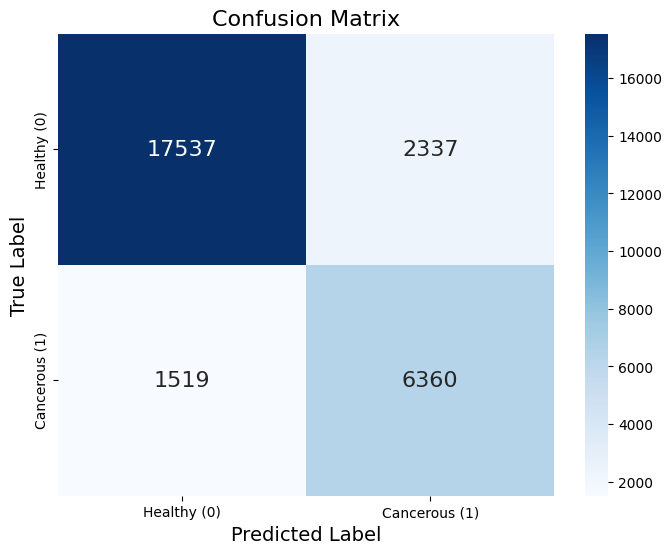


--- CLASSIFICATION REPORT ---
               precision    recall  f1-score   support

  Healthy (0)       0.92      0.88      0.90     19874
Cancerous (1)       0.73      0.81      0.77      7879

     accuracy                           0.86     27753
    macro avg       0.83      0.84      0.83     27753
 weighted avg       0.87      0.86      0.86     27753



In [ ]:
import pandas as pd
import numpy as np
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns

all_filepaths = glob('/root/.cache/kagglehub/datasets/paultimothymooney/breast-histopathology-images/versions/1/IDC_regular_ps50_idx5/**/*.png', recursive=True)
labels = ['1' if f.endswith('_class1.png') else '0' for f in all_filepaths]

df = pd.DataFrame({'filepath': all_filepaths, 'label': labels})

train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['label'])

batch_size = 64
datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_dataframe(
    dataframe=train_df, x_col='filepath', y_col='label',
    target_size=(50, 50), class_mode='binary', batch_size=batch_size, shuffle=True
)

val_generator = datagen.flow_from_dataframe(
    dataframe=val_df, x_col='filepath', y_col='label',
    target_size=(50, 50), class_mode='binary', batch_size=batch_size, shuffle=False
)

test_generator = datagen.flow_from_dataframe(
    dataframe=test_df, x_col='filepath', y_col='label',
    target_size=(50, 50), class_mode='binary', batch_size=batch_size, shuffle=False
)

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(50, 50, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Recall()])

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)
class_weights = {0: class_weights_array[0], 1: class_weights_array[1]}

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=[early_stop]
)

test_generator.reset()
y_pred_prob = model.predict(test_generator)

y_pred = (y_pred_prob > 0.5).astype(int)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy (0)', 'Cancerous (1)'],
            yticklabels=['Healthy (0)', 'Cancerous (1)'],
            annot_kws={"size": 16})

plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.show()

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=['Healthy (0)', 'Cancerous (1)']))